<a href="https://colab.research.google.com/github/CarlosGer7/MetodosNum/blob/main/M%C3%A9todo_de_Bisecci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Método de Bisección (Algoritmo 2.1 - Burden)
**Estudiante:** [Carlos Germain Leon Espinoza]
**Ejemplo de libro 1:** $f(x) = x^3 + 4x^2 - 10$

### Planteamiento del probleja del ejemplo 1 del capítulo 2  
Se busca encontrar la raíz de $f(x) = x^3 + 4x^2 - 10$ en el intervalo $[1, 2]$ con una tolerancia de $10^{-4}$.

Sabemos que $f(1) = -5$ y $f(2) = 14$. Como hay un cambio de signo, el método de bisección garantiza la convergencia.

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definimos la función del Ejemplo 1

In [106]:
def funcion1(x):
    return x**3 + 4*x**2 - 10

# Parámetros iniciales

In [107]:
a0 = 1.0
b0 = 2.0
tol = 1e-4
nmax = 100

# Inicialización

In [108]:
niter = 1
a = a0
b = b0
fa = funcion1(a)
fb = funcion1(b)
error = (b - a) / 2

# Lista para guardar los datos de la tabla

In [109]:
datos = []

# Ciclo iterativo


In [110]:
while error > tol and niter <= nmax:
    # 1. Calcular el punto medio
    m = a + (b - a) / 2
    fm = funcion1(m)

    # Guardar datos para la tabla
    datos.append({
        'n': niter,
        'a_n': a,
        'b_n': b,
        'p_n (m)': m,
        'f(p_n)': fm,
        'Error': error
    })

    # 2. Evaluar el criterio de parada
    if fm == 0 or error < tol:
        break

    # 3. Actualizar el intervalo
    if np.sign(fa) == np.sign(fm):
        a = m
        fa = fm
    else:
        b = m
        fb = fm

    # 4. Actualizar el error
    error = (b - a) / 2
    niter += 1

# Generación para la tabla

In [113]:

df_tabla = pd.DataFrame(datos)
print("Tabla de Iteraciones")
display(df_tabla)

print(f"\n✅ La raíz aproximada es: {m:.9f}")
print(f"✅ El valor de f(m) es: {fm:.9f}")
print(f"✅ Iteraciones realizadas: {niter-1}")

Tabla de Iteraciones


,n,a_n,b_n,p_n (m),f(p_n),Error
0,1,1.000000,2.000000,1.500000,2.375000,0.500000
1,2,1.000000,1.500000,1.250000,-1.796875,0.250000
2,3,1.250000,1.500000,1.375000,0.162109,0.125000
3,4,1.250000,1.375000,1.312500,-0.848389,0.062500
4,5,1.312500,1.375000,1.343750,-0.350983,0.031250
5,6,1.343750,1.375000,1.359375,-0.096409,0.015625
6,7,1.359375,1.375000,1.367188,0.032356,0.007812
7,8,1.359375,1.367188,1.363281,-0.032150,0.003906
8,9,1.363281,1.367188,1.365234,0.000072,0.001953
9,10,1.363281,1.365234,1.364258,-0.016047,0.000977



✅ La raíz aproximada es: 1.365112305
✅ El valor de f(m) es: -0.001943659
✅ Iteraciones realizadas: 13


# Gráfica

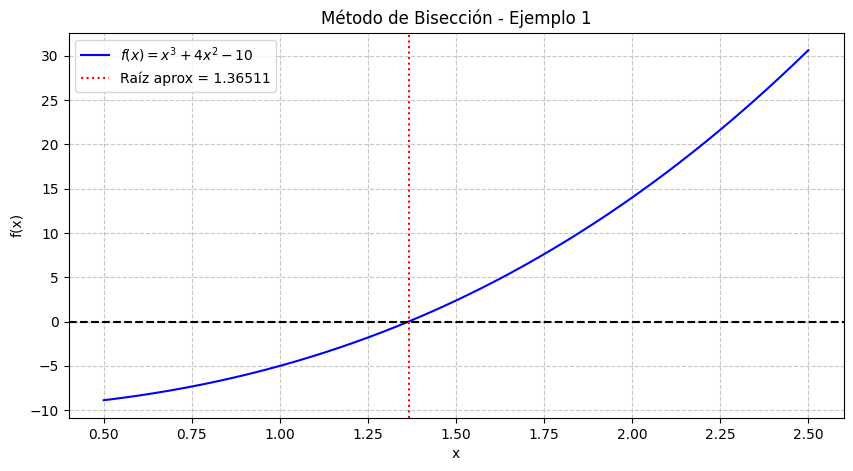

In [112]:
x_vals = np.linspace(0.5, 2.5, 400)
y_vals = funcion1(x_vals)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='$f(x) = x^3 + 4x^2 - 10$', color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(m, color='red', linestyle=':', label=f'Raíz aprox = {m:.5f}')
plt.title('Método de Bisección - Ejemplo 1')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Conclusiones
1. **Resultado:** Se encontró la raíz de la función en $x \approx 1.3652$.
2. **Iteraciones:** El método requirió 13 iteraciones para alcanzar la tolerancia de $10^{-4}$, lo cual coincide con la Tabla 2.1 del libro de Burden.
3. **Análisis:** El método de bisección es robusto pero de convergencia lenta (lineal). La cota de error disminuye a la mitad en cada iteración.